# 06 — Classical downstream benchmark

Random Forest, XGBoost, LightGBM, and Linear SVM are trained on Original
and five frozen augmentation variants. All conditions share the same
locked preprocessing, partitions, seeds, and hyperparameters. Model
choice is based on validation Macro-F1. Test results are then computed
as the final protocol-reconciliation evaluation.

Because this partition was inspected in older iterations, the report
calls it a **fixed evaluation partition reused for protocol
reconciliation**, not a pristine never-seen test set.

In [1]:
import json, os, platform, time, warnings
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import softmax
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, matthews_corrcoef, roc_auc_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")
PROFILE = os.getenv("REVALIDATION_PROFILE", "research").strip().lower()
REPORTABLE = PROFILE == "research"
SEEDS = [42] if PROFILE == "smoke" else [7, 42, 73]

In [2]:
from pathlib import Path

def resolve_project_root() -> Path:
    starts = [Path.cwd().resolve()]
    try:
        starts.append(Path(__file__).resolve().parent)
    except NameError:
        pass
    for start in starts:
        for candidate in [start, *start.parents]:
            if candidate.name == "Marco_Revalidation_v2":
                return candidate
            nested = candidate / "Marco_Revalidation_v2"
            if (nested / "00_protocol").exists():
                return nested
    raise FileNotFoundError(
        "Could not locate Marco_Revalidation_v2. Run this notebook from inside "
        "the extracted project directory."
    )

PROJECT_ROOT = resolve_project_root()
CONTRACT_DIR = PROJECT_ROOT / "01_data_contract"
CLASSICAL_DIR = PROJECT_ROOT / "02_classical_augmentation" / "outputs"
CTGAN_DIR = PROJECT_ROOT / "03_ctgan"
QGAN_DIR = PROJECT_ROOT / "04_qgan"
FIDELITY_DIR = PROJECT_ROOT / "05_fidelity"
DOWNSTREAM_DIR = PROJECT_ROOT / "06_downstream"
HANDOFF_DIR = PROJECT_ROOT / "07_quantum_handoff"
REPORT_DIR = PROJECT_ROOT / "08_reporting"
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\HP\Desktop\Qintern\week5\Marco_Revalidation_v2


In [3]:
TARGET = "Label"
CLASS_ORDER = ["Benign", "Ransomware", "Spyware", "Trojan"]
MINORITY_CLASSES = ["Ransomware", "Spyware", "Trojan"]
SEED = 42
EXPECTED_SHA256 = "cc7a637a174ffe797e0af0375bce3c09561f0dc8b8115c0a6292718034f5012a"

required = {
    "clean": CONTRACT_DIR / "malmem2022_clean_locked.csv.gz",
    "split": CONTRACT_DIR / "split_manifest.csv",
    "preprocessor": CONTRACT_DIR / "preprocessing.joblib",
    "arrays": CONTRACT_DIR / "locked_preprocessed_splits.npz",
    "manifest": CONTRACT_DIR / "dataset_manifest.json",
}
missing = [str(path) for path in required.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Run Notebook 01 first. Missing:\n- " + "\n- ".join(missing))

dataset_manifest = json.loads(required["manifest"].read_text(encoding="utf-8"))
preprocessing = joblib.load(required["preprocessor"])
locked = np.load(required["arrays"])
clean = pd.read_csv(required["clean"], low_memory=False)

assert dataset_manifest["source_sha256"] == EXPECTED_SHA256
assert preprocessing["dataset_sha256"] == EXPECTED_SHA256
assert len(clean) == 58_062 and clean["row_id"].is_unique
assert clean["partition"].value_counts().to_dict() == {
    "train": 40_642, "validation": 8_710, "test": 8_710
}

retained_features = list(preprocessing["retained_features"])
X_train = locked["X_train"].astype(np.float64)
X_validation = locked["X_validation"].astype(np.float64)
X_test = locked["X_test"].astype(np.float64)
y_train = locked["y_train"].astype(str)
y_validation = locked["y_validation"].astype(str)
y_test = locked["y_test"].astype(str)
assert X_train.shape == (40_642, 52)
assert X_validation.shape == (8_710, 52)
assert X_test.shape == (8_710, 52)
assert np.isfinite(X_train).all() and np.isfinite(X_validation).all() and np.isfinite(X_test).all()
print("Locked contract verified:", X_train.shape, X_validation.shape, X_test.shape)

Locked contract verified: (40642, 52) (8710, 52) (8710, 52)


## 1. Load frozen selected augmentation artifacts

In [ ]:
OUTPUT_DIR = DOWNSTREAM_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
artifact_paths = {
    "SMOTE": CLASSICAL_DIR / "selected" / "selected_smote_synthetic_scaled.npz",
    "Borderline-SMOTE": CLASSICAL_DIR / "selected" / "selected_borderlinesmote_synthetic_scaled.npz",
    "ADASYN": CLASSICAL_DIR / "selected" / "selected_adasyn_synthetic_scaled.npz",
    "CTGAN": CTGAN_DIR / "outputs" / "selected" / "selected_ctgan_synthetic_scaled.npz",
    "QGAN stabilized": QGAN_DIR / "outputs" / "selected" / "selected_qgan_synthetic_scaled.npz",
}
missing = [str(p) for p in artifact_paths.values() if not p.exists()]
if missing:
    raise FileNotFoundError("Run Notebooks 02–04 first. Missing:\n- " + "\n- ".join(missing))

training_sets = {"Original": (X_train, y_train)}
distribution_rows = []
for method, path in artifact_paths.items():
    loaded = np.load(path)
    X_syn = loaded["X_synthetic"].astype(float)
    y_syn = loaded["y_synthetic"].astype(str)
    assert X_syn.shape[1] == X_train.shape[1] and np.isfinite(X_syn).all()
    training_sets[method] = (
        np.vstack([X_train, X_syn]), np.concatenate([y_train, y_syn])
    )
for method, (_, labels) in training_sets.items():
    for class_name in CLASS_ORDER:
        distribution_rows.append({
            "method": method, "class": class_name,
            "train_count": int(np.sum(labels == class_name)),
        })
pd.DataFrame(distribution_rows).to_csv(OUTPUT_DIR / "training_distributions.csv", index=False)
display(pd.DataFrame(distribution_rows).pivot(index="method", columns="class", values="train_count"))

class,Benign,Ransomware,Spyware,Trojan
method,,,,
ADASYN,20461,20461,20461,20461
Borderline-SMOTE,20461,10118,10268,10096
CTGAN,20461,20461,20461,20461
Original,20461,6670,6870,6641
QGAN stabilized,20461,13566,13666,13551
SMOTE,20461,10118,10268,10096


## 2. Fixed model factory and common metrics

In [6]:
class_to_int = {name: index for index, name in enumerate(CLASS_ORDER)}
def encode(labels):
    return np.asarray([class_to_int[x] for x in labels], dtype=int)

y_validation_i, y_test_i = encode(y_validation), encode(y_test)

def make_model(name, seed):
    if name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=350 if REPORTABLE else 60, max_features="sqrt",
            random_state=seed, n_jobs=-1, class_weight=None,
        )
    if name == "XGBoost":
        return XGBClassifier(
            n_estimators=300 if REPORTABLE else 50, max_depth=6,
            learning_rate=0.05, subsample=0.85, colsample_bytree=0.85,
            objective="multi:softprob", eval_metric="mlogloss",
            random_state=seed, n_jobs=-1, tree_method="hist",
        )
    if name == "LightGBM":
        return LGBMClassifier(
            n_estimators=300 if REPORTABLE else 50, num_leaves=31,
            learning_rate=0.05, subsample=0.85, colsample_bytree=0.85,
            objective="multiclass", random_state=seed, n_jobs=-1, verbosity=-1,
        )
    if name == "Linear SVM":
        return LinearSVC(C=1.0, dual="auto", random_state=seed, max_iter=10_000)
    raise KeyError(name)

MODEL_NAMES = ["Random Forest", "XGBoost", "LightGBM", "Linear SVM"]

def score_matrix(model, X):
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X)
    else:
        raw = model.decision_function(X)
        if raw.ndim == 1:
            raw = np.column_stack([-raw, raw])
        scores = softmax(raw, axis=1)
    return np.asarray(scores, float)

def evaluate(model, X, y_true_int):
    pred = np.asarray(model.predict(X), int)
    scores = score_matrix(model, X)
    binary = label_binarize(y_true_int, classes=np.arange(len(CLASS_ORDER)))
    record = {
        "accuracy": accuracy_score(y_true_int, pred),
        "macro_f1": f1_score(y_true_int, pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true_int, pred, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(y_true_int, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true_int, pred),
        "roc_auc_ovr_macro": roc_auc_score(
            y_true_int, scores, multi_class="ovr", average="macro",
            labels=np.arange(len(CLASS_ORDER)),
        ),
        "pr_auc_macro": average_precision_score(binary, scores, average="macro"),
    }
    per_class = f1_score(
        y_true_int, pred, labels=np.arange(len(CLASS_ORDER)),
        average=None, zero_division=0,
    )
    for class_name, value in zip(CLASS_ORDER, per_class):
        record[f"f1_{class_name.lower()}"] = value
    return record, pred

## 3. Multi-seed validation and fixed-evaluation benchmark

In [7]:
records, predictions = [], {}
for method, (X_fit, y_fit) in training_sets.items():
    y_fit_i = encode(y_fit)
    for model_name in MODEL_NAMES:
        for seed in SEEDS:
            print(method, model_name, seed)
            model = make_model(model_name, seed)
            started = time.perf_counter(); model.fit(X_fit, y_fit_i)
            fit_seconds = time.perf_counter() - started
            for partition, X_eval, y_eval in [
                ("validation", X_validation, y_validation_i),
                ("fixed_evaluation", X_test, y_test_i),
            ]:
                metrics, pred = evaluate(model, X_eval, y_eval)
                records.append({
                    "method": method, "classifier": model_name,
                    "seed": seed, "partition": partition,
                    "fit_seconds": fit_seconds, **metrics,
                })
                predictions[(method, model_name, seed, partition)] = pred

results = pd.DataFrame(records)
results.to_csv(OUTPUT_DIR / "all_classifier_results.csv", index=False)
metric_columns = ["accuracy", "macro_f1", "weighted_f1", "mcc",
                  "balanced_accuracy", "roc_auc_ovr_macro", "pr_auc_macro",
                  *[f"f1_{c.lower()}" for c in CLASS_ORDER]]
summary = results.groupby(["method", "classifier", "partition"])[metric_columns].agg(
    ["mean", "std"]
)
summary.columns = ["_".join(x) for x in summary.columns]
summary = summary.reset_index()
summary.to_csv(OUTPUT_DIR / "classifier_results_mean_std.csv", index=False)
display(summary[summary.partition.eq("fixed_evaluation")].sort_values("macro_f1_mean", ascending=False))

Original Random Forest 7
Original Random Forest 42
Original Random Forest 73
Original XGBoost 7
Original XGBoost 42
Original XGBoost 73
Original LightGBM 7
Original LightGBM 42
Original LightGBM 73
Original Linear SVM 7
Original Linear SVM 42
Original Linear SVM 73
SMOTE Random Forest 7
SMOTE Random Forest 42
SMOTE Random Forest 73
SMOTE XGBoost 7
SMOTE XGBoost 42
SMOTE XGBoost 73
SMOTE LightGBM 7
SMOTE LightGBM 42
SMOTE LightGBM 73
SMOTE Linear SVM 7
SMOTE Linear SVM 42
SMOTE Linear SVM 73
Borderline-SMOTE Random Forest 7
Borderline-SMOTE Random Forest 42
Borderline-SMOTE Random Forest 73
Borderline-SMOTE XGBoost 7
Borderline-SMOTE XGBoost 42
Borderline-SMOTE XGBoost 73
Borderline-SMOTE LightGBM 7
Borderline-SMOTE LightGBM 42
Borderline-SMOTE LightGBM 73
Borderline-SMOTE Linear SVM 7
Borderline-SMOTE Linear SVM 42
Borderline-SMOTE Linear SVM 73
ADASYN Random Forest 7
ADASYN Random Forest 42
ADASYN Random Forest 73
ADASYN XGBoost 7
ADASYN XGBoost 42
ADASYN XGBoost 73
ADASYN LightGBM 7


,method,classifier,partition,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,mcc_mean,...,pr_auc_macro_mean,pr_auc_macro_std,f1_benign_mean,f1_benign_std,f1_ransomware_mean,f1_ransomware_std,f1_spyware_mean,f1_spyware_std,f1_trojan_mean,f1_trojan_std
24,Original,LightGBM,fixed_evaluation,0.871259,0.000956,0.805054,0.001489,0.871128,0.000981,0.806228,...,0.875323,0.000823,1.000000,0.000000,0.719392,0.004152,0.778052,0.001329,0.722773,0.002306
4,ADASYN,Random Forest,fixed_evaluation,0.870800,0.000351,0.804399,0.000489,0.870695,0.000356,0.805522,...,0.868974,0.000311,0.999962,0.000066,0.721332,0.001269,0.779238,0.003642,0.717063,0.002305
32,QGAN stabilized,LightGBM,fixed_evaluation,0.870226,0.000331,0.803459,0.000510,0.870070,0.000331,0.804676,...,0.871793,0.000712,1.000000,0.000000,0.717670,0.002580,0.775487,0.001700,0.720678,0.000512
12,Borderline-SMOTE,Random Forest,fixed_evaluation,0.869575,0.000000,0.802729,0.000041,0.869532,0.000017,0.803666,...,0.868562,0.000642,0.999886,0.000000,0.722443,0.001344,0.770791,0.001927,0.717797,0.001092
0,ADASYN,LightGBM,fixed_evaluation,0.868044,0.001559,0.799825,0.002421,0.867655,0.001592,0.801540,...,0.866453,0.000637,1.000000,0.000000,0.713711,0.005617,0.768897,0.001450,0.716691,0.004267
44,SMOTE,Random Forest,fixed_evaluation,0.866552,0.000692,0.798225,0.001089,0.866558,0.000721,0.799126,...,0.867214,0.000679,0.999924,0.000066,0.716055,0.002721,0.763982,0.001667,0.712941,0.000658
36,QGAN stabilized,Random Forest,fixed_evaluation,0.866475,0.000574,0.798147,0.000812,0.866509,0.000532,0.799017,...,0.867344,0.000166,0.999924,0.000066,0.716261,0.000431,0.764330,0.001544,0.712072,0.003102
20,CTGAN,Random Forest,fixed_evaluation,0.866475,0.000304,0.798137,0.000446,0.866495,0.000312,0.799014,...,0.867810,0.001006,0.999886,0.000000,0.716569,0.000545,0.765247,0.003664,0.710846,0.002279
40,SMOTE,LightGBM,fixed_evaluation,0.866628,0.001228,0.798130,0.001834,0.866539,0.001211,0.799250,...,0.867646,0.000501,1.000000,0.000000,0.712296,0.003169,0.767693,0.001836,0.712531,0.002855
8,Borderline-SMOTE,LightGBM,fixed_evaluation,0.866781,0.000976,0.798073,0.001508,0.866508,0.001000,0.799540,...,0.867105,0.000736,1.000000,0.000000,0.707059,0.004092,0.769438,0.002990,0.715797,0.001689


## 4. Validation-only selection, paired deltas, and final confusion matrix

,method,classifier,seed,partition,fit_seconds,accuracy,macro_f1,weighted_f1,mcc,balanced_accuracy,roc_auc_ovr_macro,pr_auc_macro,f1_benign,f1_ransomware,f1_spyware,f1_trojan
73,ADASYN,Random Forest,7,fixed_evaluation,17.177836,0.871183,0.804942,0.871087,0.806099,0.805033,0.969039,0.868918,1.000000,0.721346,0.783429,0.714993
75,ADASYN,Random Forest,42,fixed_evaluation,17.799381,0.870494,0.803993,0.870392,0.805053,0.804035,0.968994,0.868696,0.999886,0.722594,0.776843,0.716649
77,ADASYN,Random Forest,73,fixed_evaluation,17.628706,0.870723,0.804261,0.870607,0.805413,0.804363,0.969142,0.869310,1.000000,0.720056,0.777442,0.719547


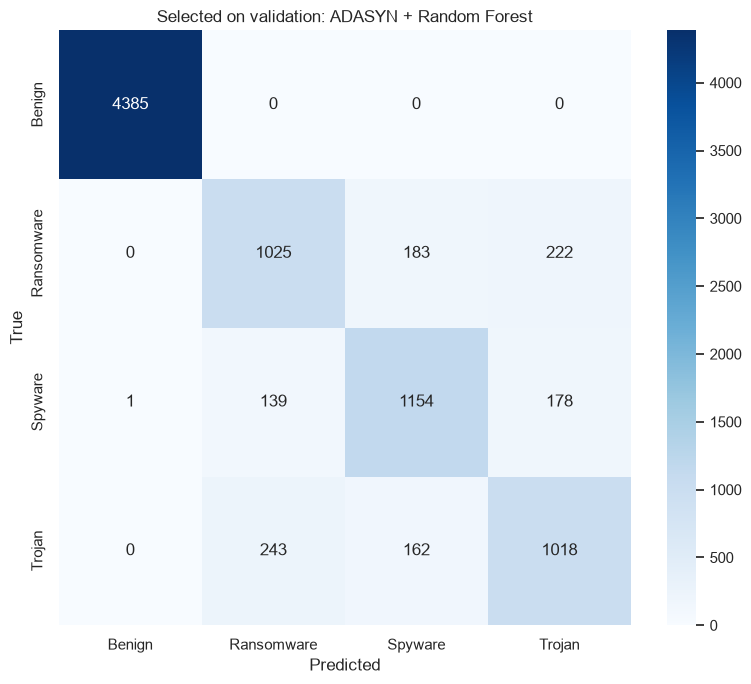

['C:\\Users\\HP\\Desktop\\Qintern\\week5\\Marco_Revalidation_v2\\06_downstream\\outputs\\selected_model_seed42.joblib']

In [ ]:
validation_summary = summary[summary.partition.eq("validation")].copy()
selected_row = validation_summary.sort_values(
    ["macro_f1_mean", "mcc_mean", "method"], ascending=[False, False, True]
).iloc[0]
selected_method = selected_row["method"]
selected_classifier = selected_row["classifier"]
selected_seed = 42 if 42 in SEEDS else SEEDS[0]

selected_test = results[
    results.method.eq(selected_method)
    & results.classifier.eq(selected_classifier)
    & results.partition.eq("fixed_evaluation")
]
display(selected_test)

augmented = results[results.method.ne("Original")].merge(
    results[results.method.eq("Original")],
    on=["classifier", "seed", "partition"],
    suffixes=("", "_original"), validate="many_to_one",
)
for metric in ["macro_f1", "mcc", "f1_trojan"]:
    augmented[f"delta_{metric}"] = augmented[metric] - augmented[f"{metric}_original"]
augmented.to_csv(OUTPUT_DIR / "paired_improvement_over_original.csv", index=False)

pred = predictions[(selected_method, selected_classifier, selected_seed, "fixed_evaluation")]
matrix = confusion_matrix(y_test_i, pred, labels=np.arange(len(CLASS_ORDER)))
pd.DataFrame(matrix, index=CLASS_ORDER, columns=CLASS_ORDER).to_csv(
    OUTPUT_DIR / "selected_confusion_matrix.csv"
)
plt.figure(figsize=(8, 7)); sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues",
                                        xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
plt.title(f"Selected on validation: {selected_method} + {selected_classifier}")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_selected_confusion_matrix.png", dpi=180); plt.show()

X_fit, y_fit = training_sets[selected_method]
selected_model = make_model(selected_classifier, selected_seed)
selected_model.fit(X_fit, encode(y_fit))
joblib.dump(selected_model, OUTPUT_DIR / "selected_model_seed42.joblib")

## 5. Figures and decision manifest

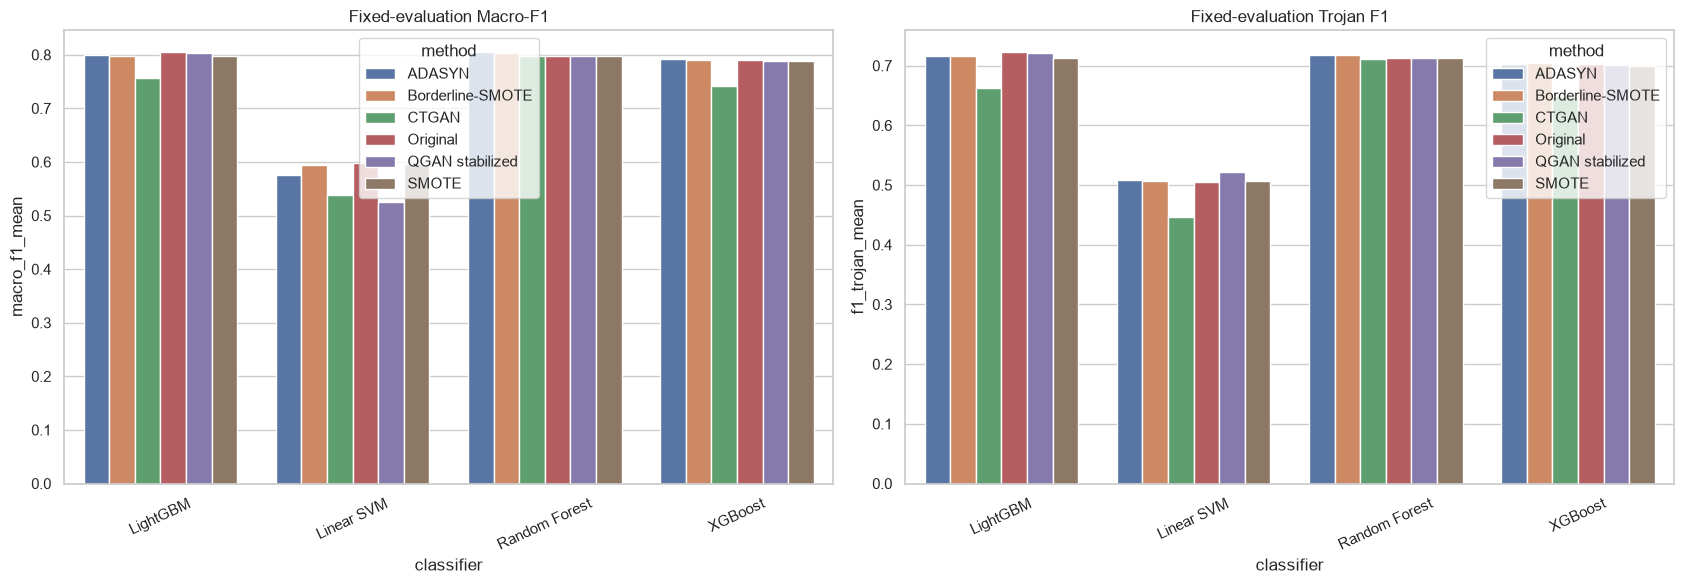

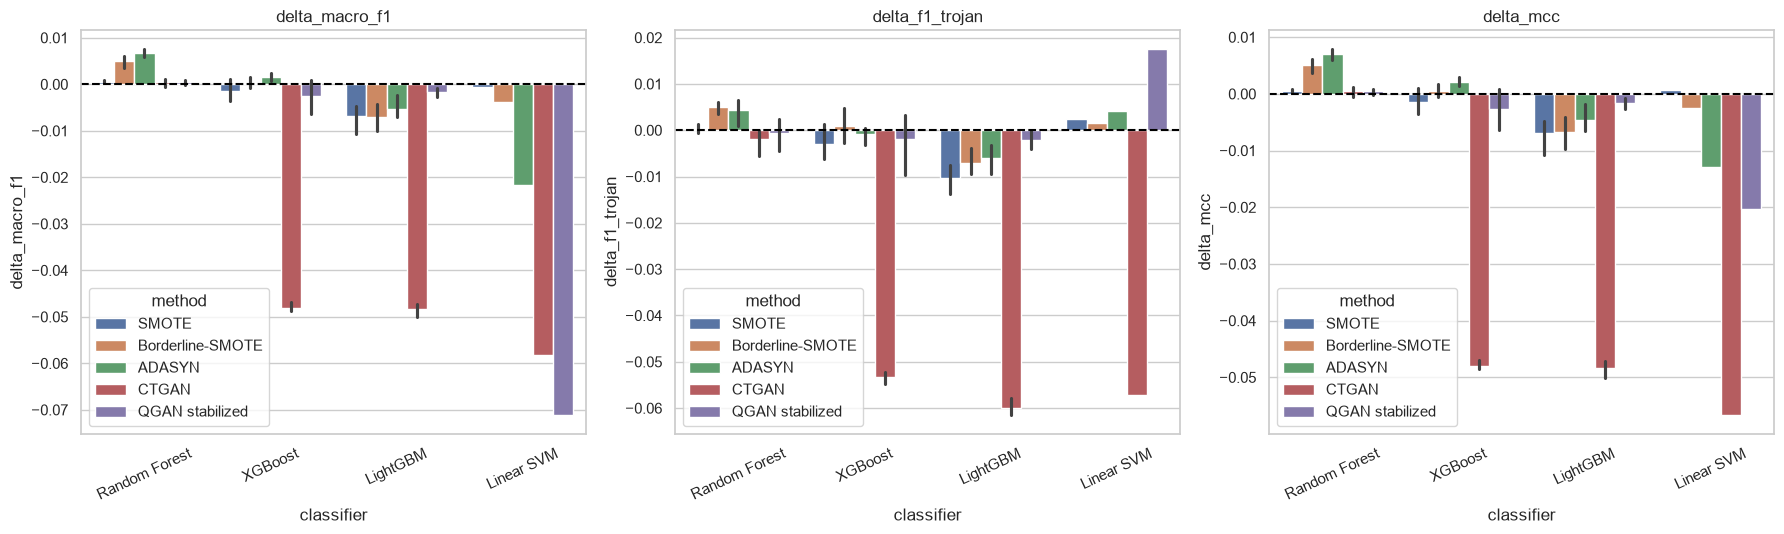

DOWNSTREAM STAGE ACCEPTED {'protocol_version': 'revalidation_v2_downstream_v1', 'created_at_utc': '2026-08-11T22:49:10.584457+00:00', 'profile': 'research', 'reportable': True, 'dataset_sha256': 'cc7a637a174ffe797e0af0375bce3c09561f0dc8b8115c0a6292718034f5012a', 'seeds': [7, 42, 73], 'methods': ['Original', 'SMOTE', 'Borderline-SMOTE', 'ADASYN', 'CTGAN', 'QGAN stabilized'], 'classifiers': ['Random Forest', 'XGBoost', 'LightGBM', 'Linear SVM'], 'selection_partition': 'validation', 'selected_method': 'ADASYN', 'selected_classifier': 'Random Forest', 'selected_validation_macro_f1_mean': 0.8119258528375993, 'evaluation_partition_description': 'fixed evaluation partition reused for protocol reconciliation; inspected in older project iterations', 'test_stage_reached': True, 'no_post_test_retuning_declared': True, 'software': {'python': '3.12.0'}}


In [9]:
plot = summary[summary.partition.eq("fixed_evaluation")].copy()
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.barplot(data=plot, x="classifier", y="macro_f1_mean", hue="method", ax=axes[0])
sns.barplot(data=plot, x="classifier", y="f1_trojan_mean", hue="method", ax=axes[1])
axes[0].set_title("Fixed-evaluation Macro-F1"); axes[1].set_title("Fixed-evaluation Trojan F1")
for ax in axes: ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "01_macro_and_trojan_f1.png", dpi=180); plt.show()

delta_plot = augmented[augmented.partition.eq("fixed_evaluation")].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, metric in zip(axes, ["delta_macro_f1", "delta_f1_trojan", "delta_mcc"]):
    sns.barplot(data=delta_plot, x="classifier", y=metric, hue="method", ax=ax)
    ax.axhline(0, color="black", linestyle="--"); ax.tick_params(axis="x", rotation=25)
    ax.set_title(metric)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "02_improvement_over_original.png", dpi=180); plt.show()

decision = {
    "protocol_version": "revalidation_v2_downstream_v1",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "profile": PROFILE, "reportable": REPORTABLE,
    "dataset_sha256": EXPECTED_SHA256,
    "seeds": SEEDS, "methods": list(training_sets), "classifiers": MODEL_NAMES,
    "selection_partition": "validation",
    "selected_method": selected_method,
    "selected_classifier": selected_classifier,
    "selected_validation_macro_f1_mean": float(selected_row["macro_f1_mean"]),
    "evaluation_partition_description": (
        "fixed evaluation partition reused for protocol reconciliation; "
        "inspected in older project iterations"
    ),
    "test_stage_reached": True,
    "no_post_test_retuning_declared": True,
    "software": {"python": platform.python_version()},
}
(OUTPUT_DIR / "downstream_decision.json").write_text(json.dumps(decision, indent=2), encoding="utf-8")
print("DOWNSTREAM STAGE ACCEPTED", decision)